# 📊 Tổng Hợp Các Đồ Thị Trong Dự Án
## Visualization Dashboard - All Charts

Notebook này hiển thị tất cả các đồ thị và biểu đồ từ dự án MXH Anomaly Detection

## 1. Setup & Imports

In [19]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Paths
PROJECT_DIR = Path(".")
GOLD_DIR = PROJECT_DIR / "data" / "gold"
CATEGORY = "All_Beauty"
DATA_DIR = GOLD_DIR / CATEGORY
ANOMALY_DIR = DATA_DIR / "anomaly_detection"
HYBRID_DIR = DATA_DIR / "hybrid_model"

print("✓ Setup completed")
print(f"Data directory: {DATA_DIR}")

✓ Setup completed
Data directory: data/gold/All_Beauty


## 2. Load Data

In [20]:
# Load nodes and edges
nodes_user = pd.read_parquet(DATA_DIR / "nodes_user.parquet")
nodes_review = pd.read_parquet(DATA_DIR / "nodes_review.parquet")
nodes_item = pd.read_parquet(DATA_DIR / "nodes_item.parquet")

edges_user_review = pd.read_parquet(DATA_DIR / "edges_user_review.parquet")
edges_review_item = pd.read_parquet(DATA_DIR / "edges_review_item.parquet")
edges_user_item = pd.read_parquet(DATA_DIR / "edges_user_item.parquet")
edges_review_review = pd.read_parquet(DATA_DIR / "edges_review_review.parquet")

# Load features
review_features = pd.read_parquet(DATA_DIR / "review_features.parquet")
review_splits = pd.read_parquet(DATA_DIR / "review_splits.parquet")

print(f"✓ Users: {len(nodes_user)}")
print(f"✓ Reviews: {len(nodes_review)}")
print(f"✓ Items: {len(nodes_item)}")
print(f"\nEdges:")
print(f"  - User-Review: {len(edges_user_review)}")
print(f"  - Review-Item: {len(edges_review_item)}")
print(f"  - User-Item: {len(edges_user_item)}")
print(f"  - Review-Review: {len(edges_review_review)}")

✓ Users: 588332
✓ Reviews: 644689
✓ Items: 108784

Edges:
  - User-Review: 644689
  - Review-Item: 644689
  - User-Item: 644689
  - Review-Review: 267837


In [21]:
# Load anomaly detection results if available
try:
    anomaly_scores = np.load(ANOMALY_DIR / "hybrid_anomaly_scores.npy")
    anomaly_metadata = json.load(open(ANOMALY_DIR / "anomaly_metadata.json"))
    anomaly_indices = np.load(ANOMALY_DIR / "anomaly_indices.npy")
    print("✓ Anomaly detection results loaded")
except Exception as e:
    print(f"⚠ Anomaly data not found: {e}")
    anomaly_scores = None

✓ Anomaly detection results loaded


In [22]:
print("\n📋 Available Columns in DataFrames:")
print("="*60)
print(f"\nreview_features columns ({len(review_features.columns)}):")
print(list(review_features.columns))
print(f"\nreview_splits columns ({len(review_splits.columns)}):")
print(list(review_splits.columns))
print(f"\nnodes_user columns ({len(nodes_user.columns)}):")
print(list(nodes_user.columns))
print(f"\nnodes_item columns ({len(nodes_item.columns)}):")
print(list(nodes_item.columns))
print("="*60)


📋 Available Columns in DataFrames:

review_features columns (39):
['review_id', 'text_length_chars', 'text_length_words', 'num_exclamation', 'num_question', 'num_uppercase_words', 'uppercase_word_ratio', 'is_short_review', 'is_very_short_review', 'duplicate_text_count', 'rating', 'is_extreme_rating', 'rating_deviation_from_item_avg', 'rating_deviation_from_user_avg', 'helpful_vote', 'verified_purchase', 'user_review_count', 'user_item_count', 'user_avg_rating', 'user_rating_std', 'user_active_days', 'user_reviews_per_day', 'user_verified_ratio', 'user_avg_text_length', 'user_singleton', 'user_day_review_count', 'item_review_count', 'item_user_count', 'item_avg_rating', 'item_rating_std', 'item_active_days', 'item_reviews_per_day', 'item_verified_ratio', 'item_avg_text_length', 'item_day_review_count', 'item_month_review_count', 'item_rating_month_count', 'suspicion_score', 'weak_label']

review_splits columns (4):
['review_id', 'split', 'weak_label', 'suspicion_score']

nodes_user col

## 3. Biểu Đồ Phân Phối Dữ Liệu

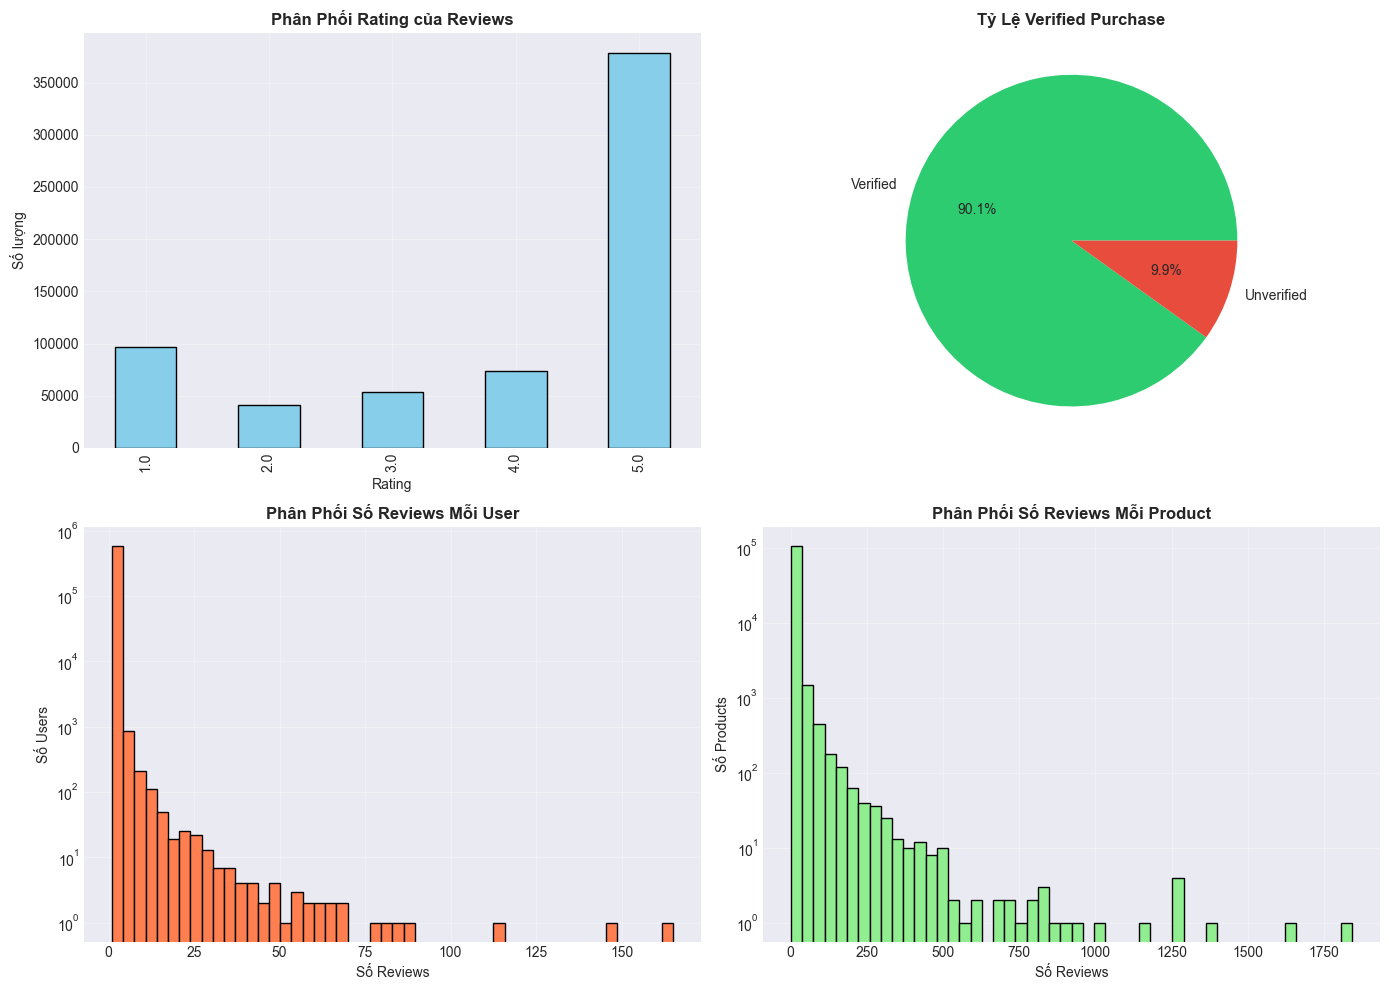

✓ Saved: 01_data_distribution.png


In [23]:
# Distribution of ratings
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating distribution
review_features['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black'
)
axes[0, 0].set_title('Phân Phối Rating của Reviews', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].grid(True, alpha=0.3)

# Verified purchase distribution
verified_counts = review_features['verified_purchase'].value_counts()
axes[0, 1].pie(
    verified_counts.values, 
    labels=['Verified', 'Unverified'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c']
)
axes[0, 1].set_title('Tỷ Lệ Verified Purchase', fontsize=12, fontweight='bold')

# Reviews per user distribution
reviews_per_user = edges_user_review.groupby('src').size()
axes[1, 0].hist(reviews_per_user.values, bins=50, color='coral', edgecolor='black')
axes[1, 0].set_title('Phân Phối Số Reviews Mỗi User', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Số Reviews')
axes[1, 0].set_ylabel('Số Users')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Reviews per item distribution
reviews_per_item = edges_review_item.groupby('dst').size()
axes[1, 1].hist(reviews_per_item.values, bins=50, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Phân Phối Số Reviews Mỗi Product', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Số Reviews')
axes[1, 1].set_ylabel('Số Products')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_data_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 01_data_distribution.png")

## 4. Biểu Đồ Đặc Trưng Reviews

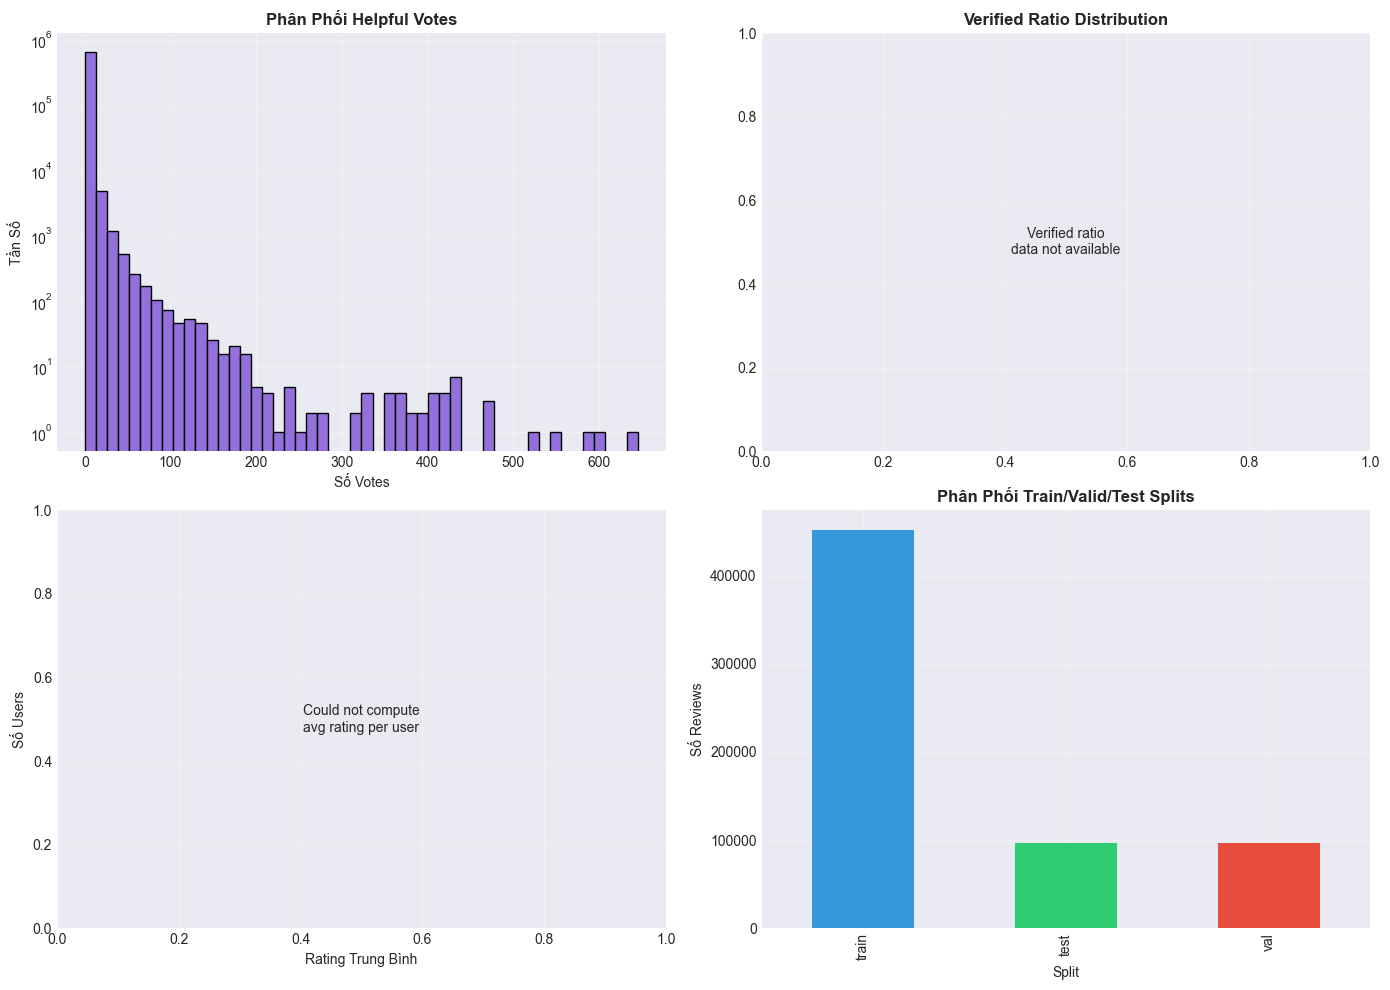

✓ Saved: 02_review_features.png


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Helpful votes distribution
if 'helpful_vote' in review_features.columns:
    axes[0, 0].hist(review_features['helpful_vote'].values, bins=50, color='mediumpurple', edgecolor='black')
    axes[0, 0].set_title('Phân Phối Helpful Votes', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Số Votes')
    axes[0, 0].set_ylabel('Tần Số')
    axes[0, 0].set_yscale('log')
else:
    axes[0, 0].text(0.5, 0.5, 'Helpful votes\ndata not available', 
                     ha='center', va='center', transform=axes[0, 0].transAxes)
axes[0, 0].grid(True, alpha=0.3)

# Verified ratio distribution
if 'verified_ratio' in review_features.columns:
    axes[0, 1].hist(review_features['verified_ratio'].values, bins=50, color='goldenrod', edgecolor='black')
    axes[0, 1].set_title('Phân Phối Verified Ratio', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Tỷ Lệ')
else:
    axes[0, 1].text(0.5, 0.5, 'Verified ratio\ndata not available', 
                     ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Verified Ratio Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Avg rating per user
if 'src' in edges_user_review.columns and 'dst' in edges_user_review.columns:
    try:
        avg_rating_per_user = review_features.groupby(edges_user_review.set_index('dst').loc[review_features.index, 'src'])['rating'].mean()
        axes[1, 0].hist(avg_rating_per_user.dropna().values, bins=30, color='lightblue', edgecolor='black')
        axes[1, 0].set_title('Phân Phối Avg Rating Mỗi User', fontsize=12, fontweight='bold')
    except Exception as e:
        axes[1, 0].text(0.5, 0.5, f'Could not compute\navg rating per user', 
                         ha='center', va='center', transform=axes[1, 0].transAxes)
else:
    axes[1, 0].text(0.5, 0.5, 'Insufficient data for\navg rating computation', 
                     ha='center', va='center', transform=axes[1, 0].transAxes)
axes[1, 0].set_xlabel('Rating Trung Bình')
axes[1, 0].set_ylabel('Số Users')
axes[1, 0].grid(True, alpha=0.3)

# Split distribution
split_counts = review_splits['split'].value_counts()
split_counts.plot(kind='bar', ax=axes[1, 1], color=['#3498db', '#2ecc71', '#e74c3c'][:len(split_counts)])
axes[1, 1].set_title('Phân Phối Train/Valid/Test Splits', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Split')
axes[1, 1].set_ylabel('Số Reviews')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_review_features.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 02_review_features.png")

## 5. Biểu Đồ Mạng Lưới (Network Graph Statistics)

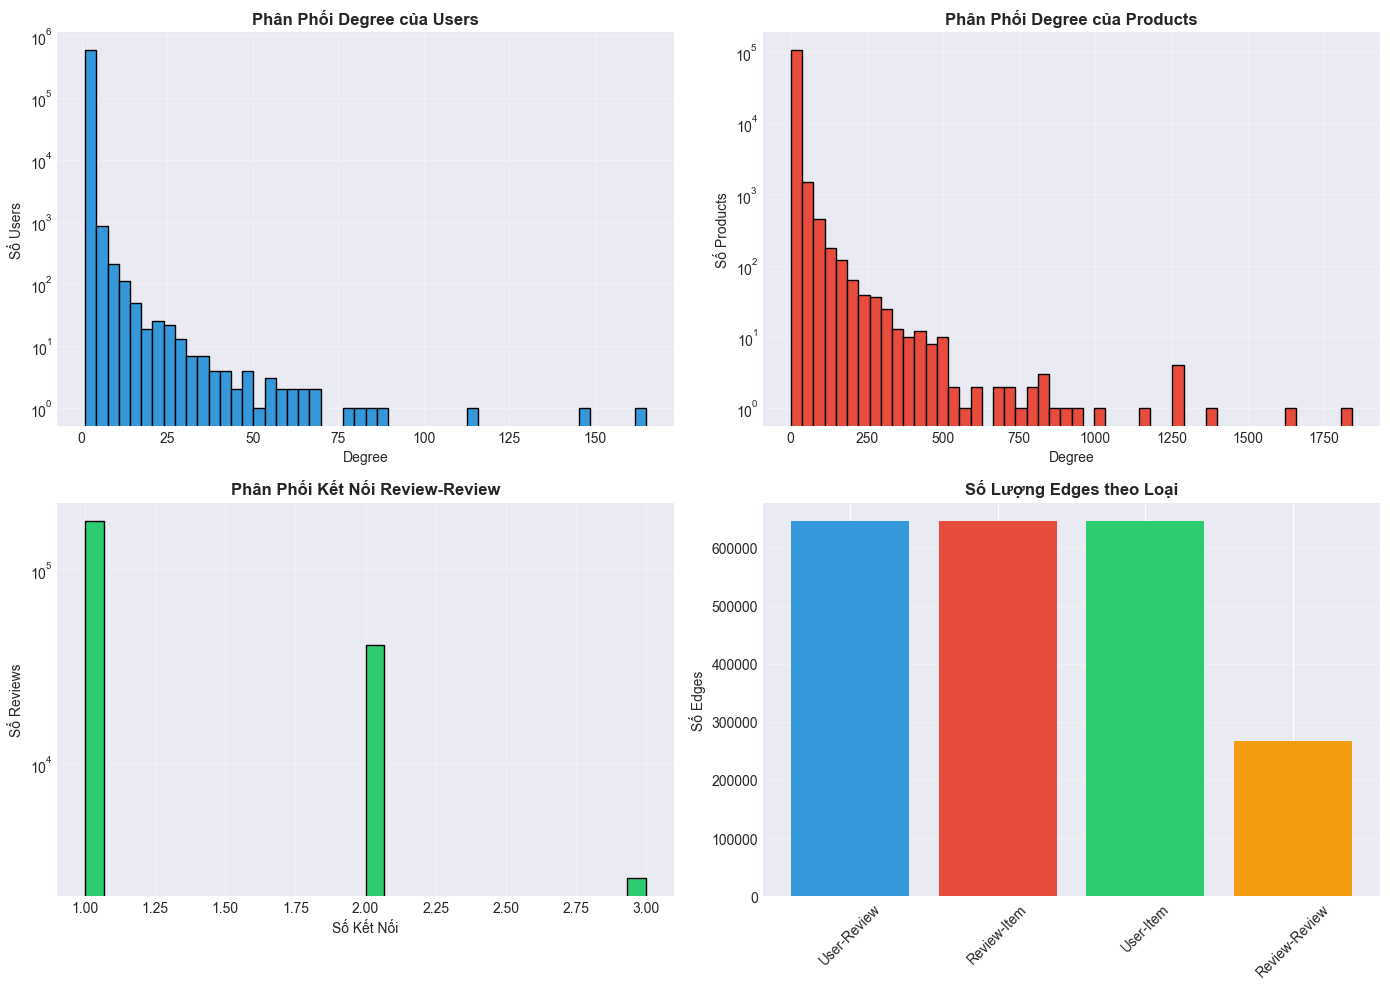

✓ Saved: 03_network_statistics.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Degree distribution - User
user_degrees = edges_user_review.groupby('src').size()
axes[0, 0].hist(user_degrees.values, bins=50, color='#3498db', edgecolor='black')
axes[0, 0].set_title('Phân Phối Degree của Users', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Degree')
axes[0, 0].set_ylabel('Số Users')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Degree distribution - Item
item_degrees = edges_review_item.groupby('dst').size()
axes[0, 1].hist(item_degrees.values, bins=50, color='#e74c3c', edgecolor='black')
axes[0, 1].set_title('Phân Phối Degree của Products', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Degree')
axes[0, 1].set_ylabel('Số Products')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Review-Review connections
review_connections = edges_review_review.groupby('src').size()
axes[1, 0].hist(review_connections.values, bins=30, color='#2ecc71', edgecolor='black')
axes[1, 0].set_title('Phân Phối Kết Nối Review-Review', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Số Kết Nối')
axes[1, 0].set_ylabel('Số Reviews')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Edge type statistics
edge_types = {
    'User-Review': len(edges_user_review),
    'Review-Item': len(edges_review_item),
    'User-Item': len(edges_user_item),
    'Review-Review': len(edges_review_review)
}
axes[1, 1].bar(edge_types.keys(), edge_types.values(), color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1, 1].set_title('Số Lượng Edges theo Loại', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Số Edges')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('03_network_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_network_statistics.png")

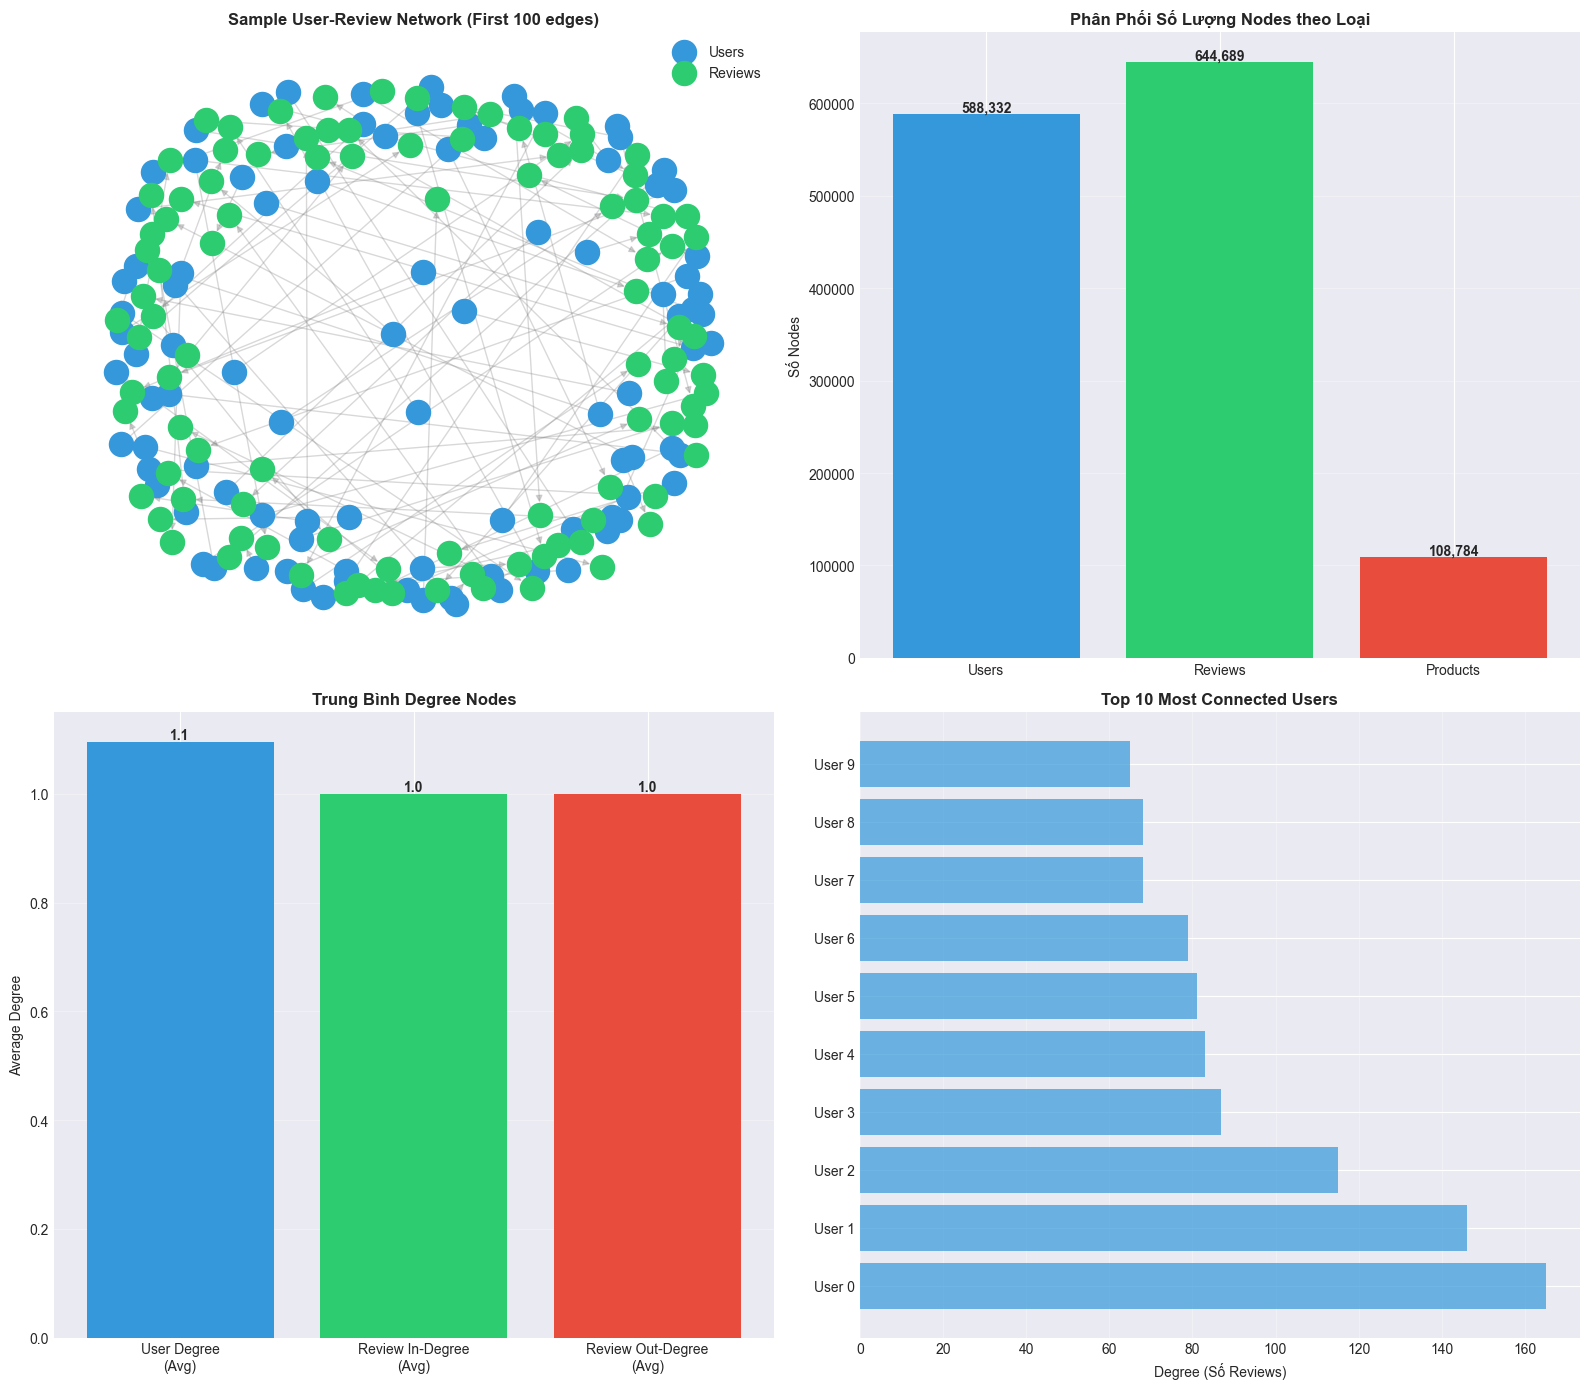

✓ Saved: 03_5_network_visualization.png


In [26]:
import networkx as nx
from matplotlib.patches import Rectangle

## 5.5 Biểu Đồ Hình Ảnh Mạng Lưới (Network Graph Visualization)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Tạo sample graph từ edges
G = nx.DiGraph()

# Add user-review edges (sample)
sample_user_review = edges_user_review.head(100)
for _, row in sample_user_review.iterrows():
    G.add_edge(f"U_{row['src']}", f"R_{row['dst']}", edge_type='user_review')

# Visualize User-Review Network
ax = axes[0, 0]
if len(G.nodes()) > 0:
    pos = nx.spring_layout(G, k=0.5, iterations=20, seed=42)
    
    # Draw nodes by type
    user_nodes = [n for n in G.nodes() if n.startswith('U_')]
    review_nodes = [n for n in G.nodes() if n.startswith('R_')]
    
    nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color='#3498db', 
                           node_size=300, label='Users', ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=review_nodes, node_color='#2ecc71', 
                           node_size=300, label='Reviews', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, arrows=True, ax=ax)
    
    ax.set_title('Sample User-Review Network (First 100 edges)', fontsize=12, fontweight='bold')
    ax.legend(scatterpoints=1)
    ax.axis('off')
else:
    ax.text(0.5, 0.5, 'No graph data available', ha='center', va='center', transform=ax.transAxes)

# Node type distribution
ax = axes[0, 1]
node_type_dist = {
    'Users': len(nodes_user),
    'Reviews': len(nodes_review),
    'Products': len(nodes_item)
}
colors_nodes = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(node_type_dist.keys(), node_type_dist.values(), color=colors_nodes)
ax.set_title('Phân Phối Số Lượng Nodes theo Loại', fontsize=12, fontweight='bold')
ax.set_ylabel('Số Nodes')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Degree statistics
ax = axes[1, 0]
user_degrees = edges_user_review.groupby('src').size()
review_in_degrees = edges_user_review.groupby('dst').size()
review_out_degrees = edges_review_item.groupby('src').size()

degree_stats = {
    'User Degree\n(Avg)': user_degrees.mean(),
    'Review In-Degree\n(Avg)': review_in_degrees.mean(),
    'Review Out-Degree\n(Avg)': review_out_degrees.mean(),
}

bars = ax.bar(degree_stats.keys(), degree_stats.values(), color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_title('Trung Bình Degree Nodes', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Degree')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Top connected nodes
ax = axes[1, 1]
top_users = user_degrees.nlargest(10)
top_reviews_in = review_in_degrees.nlargest(10)

ax.barh(range(len(top_users)), top_users.values, label='Top User Degrees', color='#3498db', alpha=0.7)
ax.set_title('Top 10 Most Connected Users', fontsize=12, fontweight='bold')
ax.set_xlabel('Degree (Số Reviews)')
ax.set_yticks(range(len(top_users)))
ax.set_yticklabels([f'User {i}' for i in range(len(top_users))])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('03_5_network_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_5_network_visualization.png")

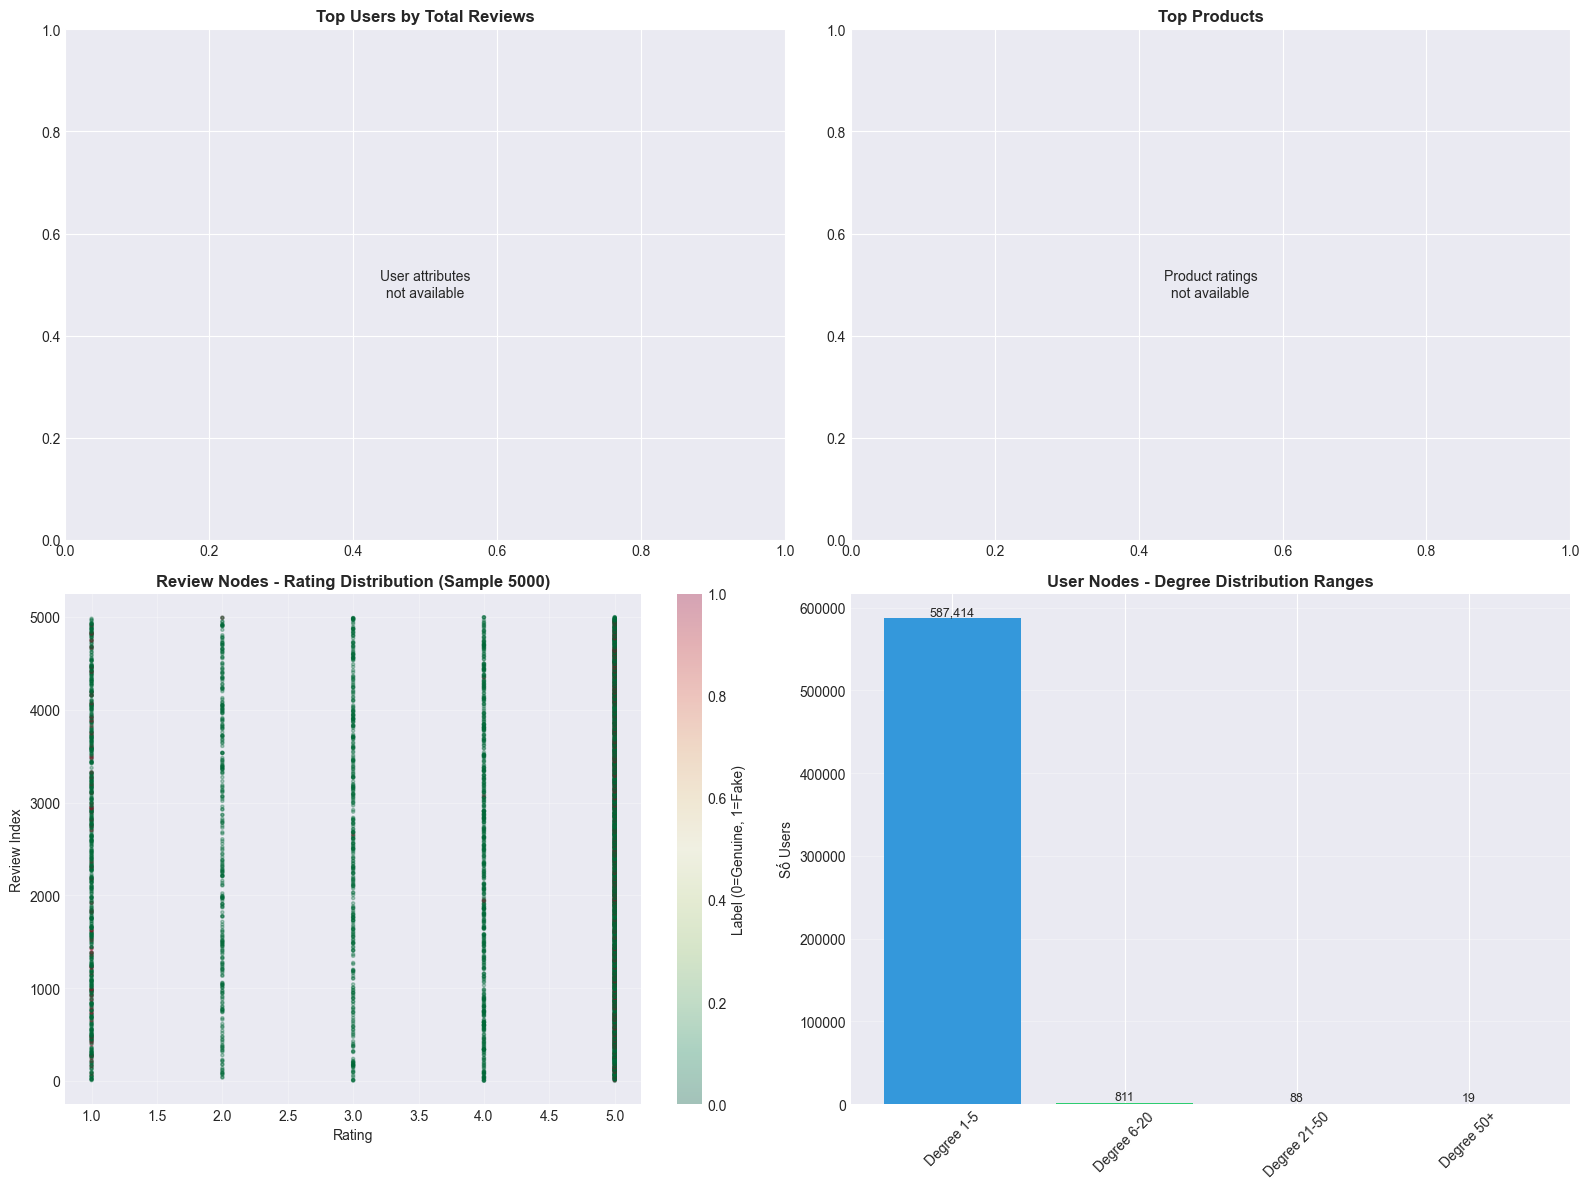

✓ Saved: 03_6_node_attributes.png


In [27]:
## 5.6 Biểu Đồ Thuộc Tính Nodes

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# User node attributes
ax = axes[0, 0]
if 'total_reviews' in nodes_user.columns:
    top_users_by_reviews = nodes_user.nlargest(15, 'total_reviews')
    ax.barh(range(len(top_users_by_reviews)), top_users_by_reviews['total_reviews'].values, color='#3498db')
    ax.set_title('Top 15 Users - Số Reviews', fontsize=12, fontweight='bold')
    ax.set_xlabel('Total Reviews')
    ax.set_yticks(range(len(top_users_by_reviews)))
    ax.set_yticklabels([f'U_{i}' for i in range(len(top_users_by_reviews))])
    ax.grid(True, alpha=0.3, axis='x')
else:
    ax.text(0.5, 0.5, 'User attributes\nnot available', ha='center', va='center', transform=ax.transAxes)
ax.set_title('Top Users by Total Reviews', fontsize=12, fontweight='bold')

# Product node attributes
ax = axes[0, 1]
if 'avg_rating' in nodes_item.columns:
    top_rated_products = nodes_item.nlargest(15, 'avg_rating')
    colors_rating = ['#2ecc71' if r >= 4 else '#f39c12' if r >= 3 else '#e74c3c' 
                     for r in top_rated_products['avg_rating']]
    ax.barh(range(len(top_rated_products)), top_rated_products['avg_rating'].values, color=colors_rating)
    ax.set_title('Top 15 Products - Average Rating', fontsize=12, fontweight='bold')
    ax.set_xlabel('Average Rating')
    ax.set_yticks(range(len(top_rated_products)))
    ax.set_yticklabels([f'P_{i}' for i in range(len(top_rated_products))])
    ax.set_xlim(0, 5)
    ax.grid(True, alpha=0.3, axis='x')
else:
    ax.text(0.5, 0.5, 'Product ratings\nnot available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Top Products', fontsize=12, fontweight='bold')

# Node connectivity heatmap (degree vs rating)
ax = axes[1, 0]
if len(review_features) > 0 and 'rating' in review_features.columns:
    # Create bins for degree and rating
    review_degree_in = edges_user_review.groupby('dst').size()
    review_degree_out = edges_review_item.groupby('src').size()
    
    # Sample data for visualization (too many points otherwise)
    sample_size = min(5000, len(review_features))
    sample_idx = np.random.choice(len(review_features), sample_size, replace=False)
    
    sample_ratings = review_features.iloc[sample_idx]['rating'].values
    sample_labels = review_splits.iloc[sample_idx]['weak_label'].values
    
    scatter = ax.scatter(sample_ratings, range(len(sample_ratings)), 
                        c=sample_labels, cmap='RdYlGn_r', alpha=0.3, s=5)
    ax.set_title(f'Review Nodes - Rating Distribution (Sample {sample_size})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Review Index')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Label (0=Genuine, 1=Fake)')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Review data\nnot available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Review Nodes', fontsize=12, fontweight='bold')

# Node count by category
ax = axes[1, 1]
if len(nodes_item) > 0:
    # Count nodes in different degree ranges
    degree_ranges = {
        'Degree 1-5': len([d for d in user_degrees if 1 <= d <= 5]),
        'Degree 6-20': len([d for d in user_degrees if 6 <= d <= 20]),
        'Degree 21-50': len([d for d in user_degrees if 21 <= d <= 50]),
        'Degree 50+': len([d for d in user_degrees if d > 50]),
    }
    
    colors_deg = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
    bars = ax.bar(degree_ranges.keys(), degree_ranges.values(), color=colors_deg)
    ax.set_title('User Nodes - Degree Distribution Ranges', fontsize=12, fontweight='bold')
    ax.set_ylabel('Số Users')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('03_6_node_attributes.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_6_node_attributes.png")

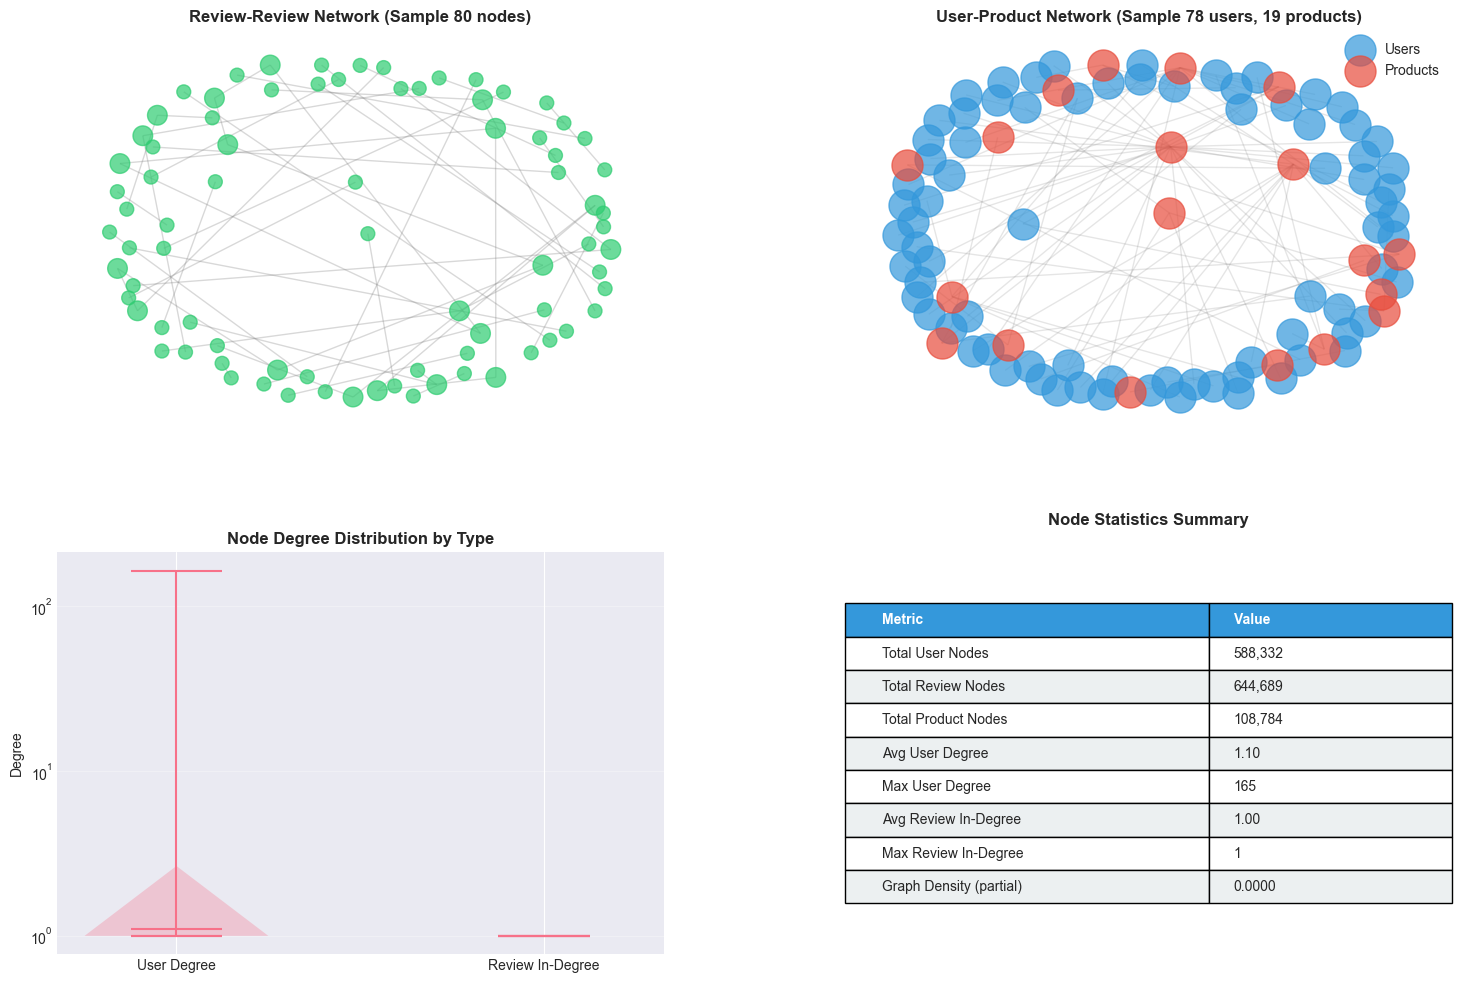

✓ Saved: 03_7_detailed_graph_visualization.png


In [28]:
## 5.7 Biểu Đồ Graph Visualization Chi Tiết

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Review-Review Network Sample
ax1 = fig.add_subplot(gs[0, 0])
G_review = nx.Graph()

# Add sample review-review edges
sample_review_edges = edges_review_review.head(50)
for _, row in sample_review_edges.iterrows():
    G_review.add_edge(f"R{row['src']}", f"R{row['dst']}")

if len(G_review.nodes()) > 0:
    pos_review = nx.spring_layout(G_review, k=1, iterations=30, seed=42)
    
    # Size nodes by their degree
    node_sizes = [G_review.degree(n) * 100 for n in G_review.nodes()]
    
    nx.draw_networkx_nodes(G_review, pos_review, node_color='#2ecc71', 
                          node_size=node_sizes, alpha=0.7, ax=ax1)
    nx.draw_networkx_edges(G_review, pos_review, edge_color='gray', alpha=0.3, ax=ax1)
    
    ax1.set_title(f'Review-Review Network (Sample {len(G_review.nodes())} nodes)', 
                 fontsize=12, fontweight='bold')
    ax1.axis('off')
else:
    ax1.text(0.5, 0.5, 'No review-review data', ha='center', va='center', transform=ax1.transAxes)

# 2. User-Product Bipartite Network
ax2 = fig.add_subplot(gs[0, 1])
G_bipartite = nx.Graph()

# Sample user-item edges
sample_user_item = edges_user_item.head(80)
for _, row in sample_user_item.iterrows():
    G_bipartite.add_edge(f"U{row['src']}", f"I{row['dst']}")

if len(G_bipartite.nodes()) > 0:
    pos_bipartite = nx.spring_layout(G_bipartite, k=1.5, iterations=30, seed=42)
    
    # Draw users and items differently
    users = [n for n in G_bipartite.nodes() if n.startswith('U')]
    items = [n for n in G_bipartite.nodes() if n.startswith('I')]
    
    nx.draw_networkx_nodes(G_bipartite, pos_bipartite, nodelist=users, 
                          node_color='#3498db', node_size=500, alpha=0.7, label='Users', ax=ax2)
    nx.draw_networkx_nodes(G_bipartite, pos_bipartite, nodelist=items, 
                          node_color='#e74c3c', node_size=500, alpha=0.7, label='Products', ax=ax2)
    nx.draw_networkx_edges(G_bipartite, pos_bipartite, edge_color='gray', alpha=0.2, ax=ax2)
    
    ax2.set_title(f'User-Product Network (Sample {len(users)} users, {len(items)} products)', 
                 fontsize=12, fontweight='bold')
    ax2.legend(scatterpoints=1)
    ax2.axis('off')
else:
    ax2.text(0.5, 0.5, 'No user-product data', ha='center', va='center', transform=ax2.transAxes)

# 3. Node Degree Distribution - All Types
ax3 = fig.add_subplot(gs[1, 0])

degrees_data = []
labels_data = []

# User degrees
user_deg_vals = list(user_degrees.values)
degrees_data.extend(user_deg_vals)
labels_data.extend(['User'] * len(user_deg_vals))

# Review-in degrees
review_in_vals = list(review_in_degrees.values)
degrees_data.extend(review_in_vals)
labels_data.extend(['Review-In'] * len(review_in_vals))

# Create violin plot or box plot
parts = ax3.violinplot([user_deg_vals, review_in_vals], 
                        positions=[1, 2], showmeans=True, showmedians=True)
ax3.set_title('Node Degree Distribution by Type', fontsize=12, fontweight='bold')
ax3.set_ylabel('Degree')
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['User Degree', 'Review In-Degree'])
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Node Statistics Summary Table
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

stats_data = [
    ['Metric', 'Value'],
    ['Total User Nodes', f'{len(nodes_user):,}'],
    ['Total Review Nodes', f'{len(nodes_review):,}'],
    ['Total Product Nodes', f'{len(nodes_item):,}'],
    ['Avg User Degree', f'{user_degrees.mean():.2f}'],
    ['Max User Degree', f'{user_degrees.max():.0f}'],
    ['Avg Review In-Degree', f'{review_in_degrees.mean():.2f}'],
    ['Max Review In-Degree', f'{review_in_degrees.max():.0f}'],
    ['Graph Density (partial)', f'{len(edges_user_review) / (len(nodes_user) * len(nodes_review)):.4f}'],
]

table = ax4.table(cellText=stats_data, cellLoc='left', loc='center',
                 colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(len(stats_data[0])):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(stats_data)):
    for j in range(len(stats_data[0])):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax4.set_title('Node Statistics Summary', fontsize=12, fontweight='bold', pad=20)

plt.savefig('03_7_detailed_graph_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_7_detailed_graph_visualization.png")

## 6. Biểu Đồ Weak Labels

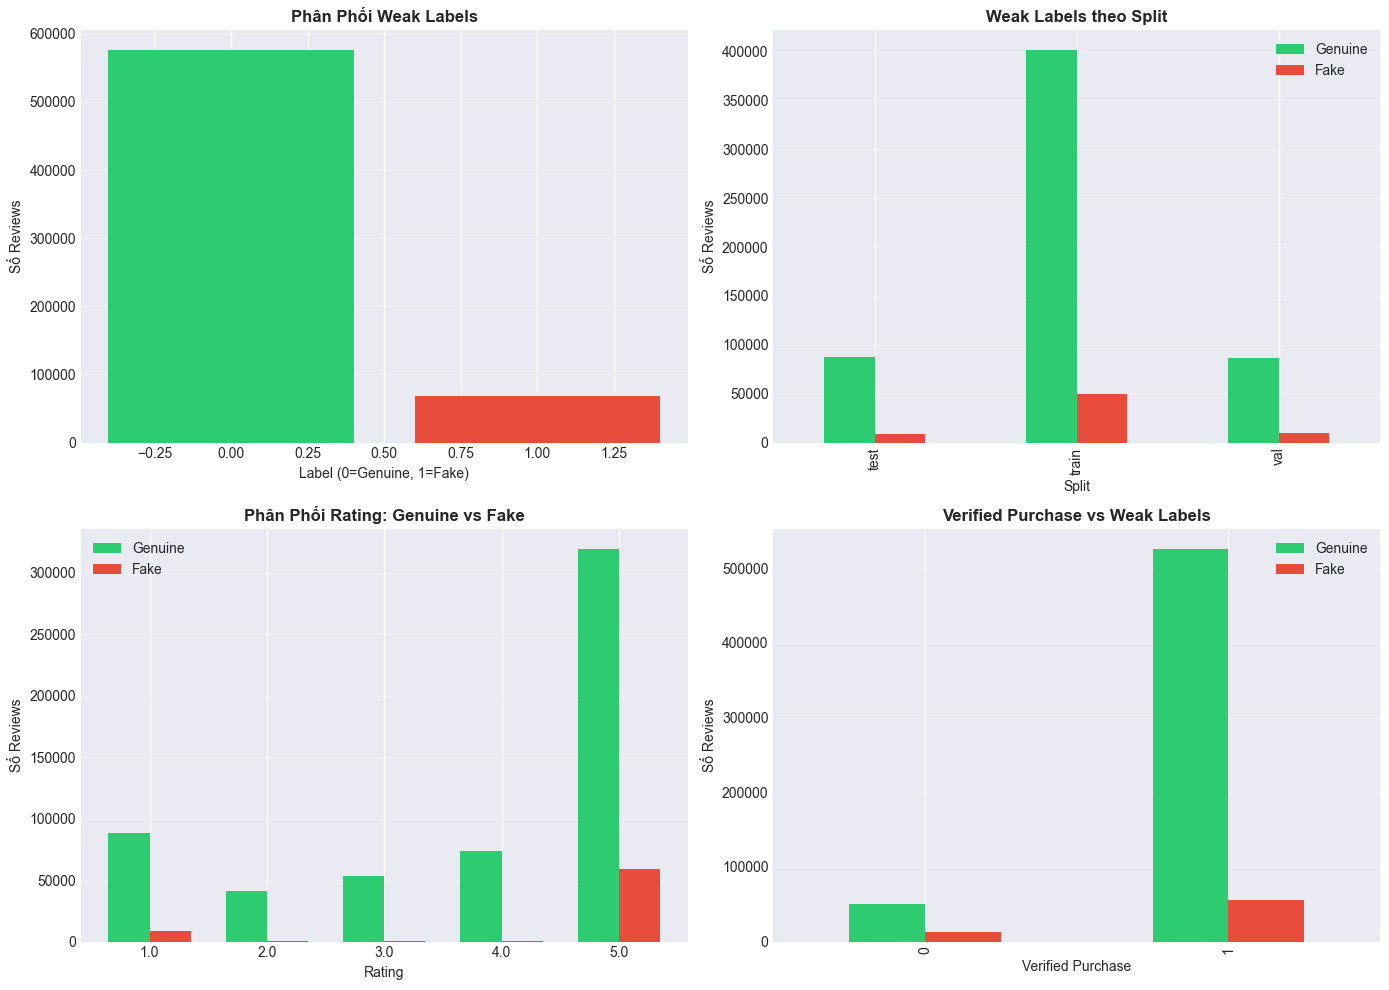

✓ Saved: 04_weak_labels.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall weak label distribution
label_counts = review_splits['weak_label'].value_counts()
label_colors = ['#2ecc71', '#e74c3c']  # green for negative (0), red for positive (1)
axes[0, 0].bar(label_counts.index, label_counts.values, color=label_colors[:len(label_counts)])
axes[0, 0].set_title('Phân Phối Weak Labels', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Label (0=Genuine, 1=Fake)')
axes[0, 0].set_ylabel('Số Reviews')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Weak label distribution by split
split_label_dist = pd.crosstab(review_splits['split'], review_splits['weak_label'])
split_label_dist.plot(kind='bar', ax=axes[0, 1], color=label_colors[:split_label_dist.shape[1]])
axes[0, 1].set_title('Weak Labels theo Split', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Split')
axes[0, 1].set_ylabel('Số Reviews')
axes[0, 1].legend(['Genuine', 'Fake'][:split_label_dist.shape[1]])
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Weak label vs Rating
try:
    fake_ratings = review_features[review_splits['weak_label'] == 1]['rating'].value_counts().sort_index()
    genuine_ratings = review_features[review_splits['weak_label'] == 0]['rating'].value_counts().sort_index()

    x = np.arange(len(genuine_ratings))
    width = 0.35
    axes[1, 0].bar(x - width/2, genuine_ratings.values, width, label='Genuine', color='#2ecc71')
    axes[1, 0].bar(x + width/2, fake_ratings.values, width, label='Fake', color='#e74c3c')
    axes[1, 0].set_title('Phân Phối Rating: Genuine vs Fake', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Rating')
    axes[1, 0].set_ylabel('Số Reviews')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(genuine_ratings.index)
    axes[1, 0].legend()
except Exception as e:
    axes[1, 0].text(0.5, 0.5, f'Could not compute\nrating distribution', 
                     ha='center', va='center', transform=axes[1, 0].transAxes)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Weak label vs Verified Purchase
try:
    verified_vs_label = pd.crosstab(review_features['verified_purchase'], review_splits['weak_label'])
    verified_vs_label.plot(kind='bar', ax=axes[1, 1], color=label_colors[:verified_vs_label.shape[1]])
    axes[1, 1].set_title('Verified Purchase vs Weak Labels', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Verified Purchase')
    axes[1, 1].set_ylabel('Số Reviews')
    axes[1, 1].legend(['Genuine', 'Fake'][:verified_vs_label.shape[1]])
except Exception as e:
    axes[1, 1].text(0.5, 0.5, f'Verified purchase data\nnot available', 
                     ha='center', va='center', transform=axes[1, 1].transAxes)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('04_weak_labels.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 04_weak_labels.png")

## 7. Biểu Đồ Anomaly Detection Results

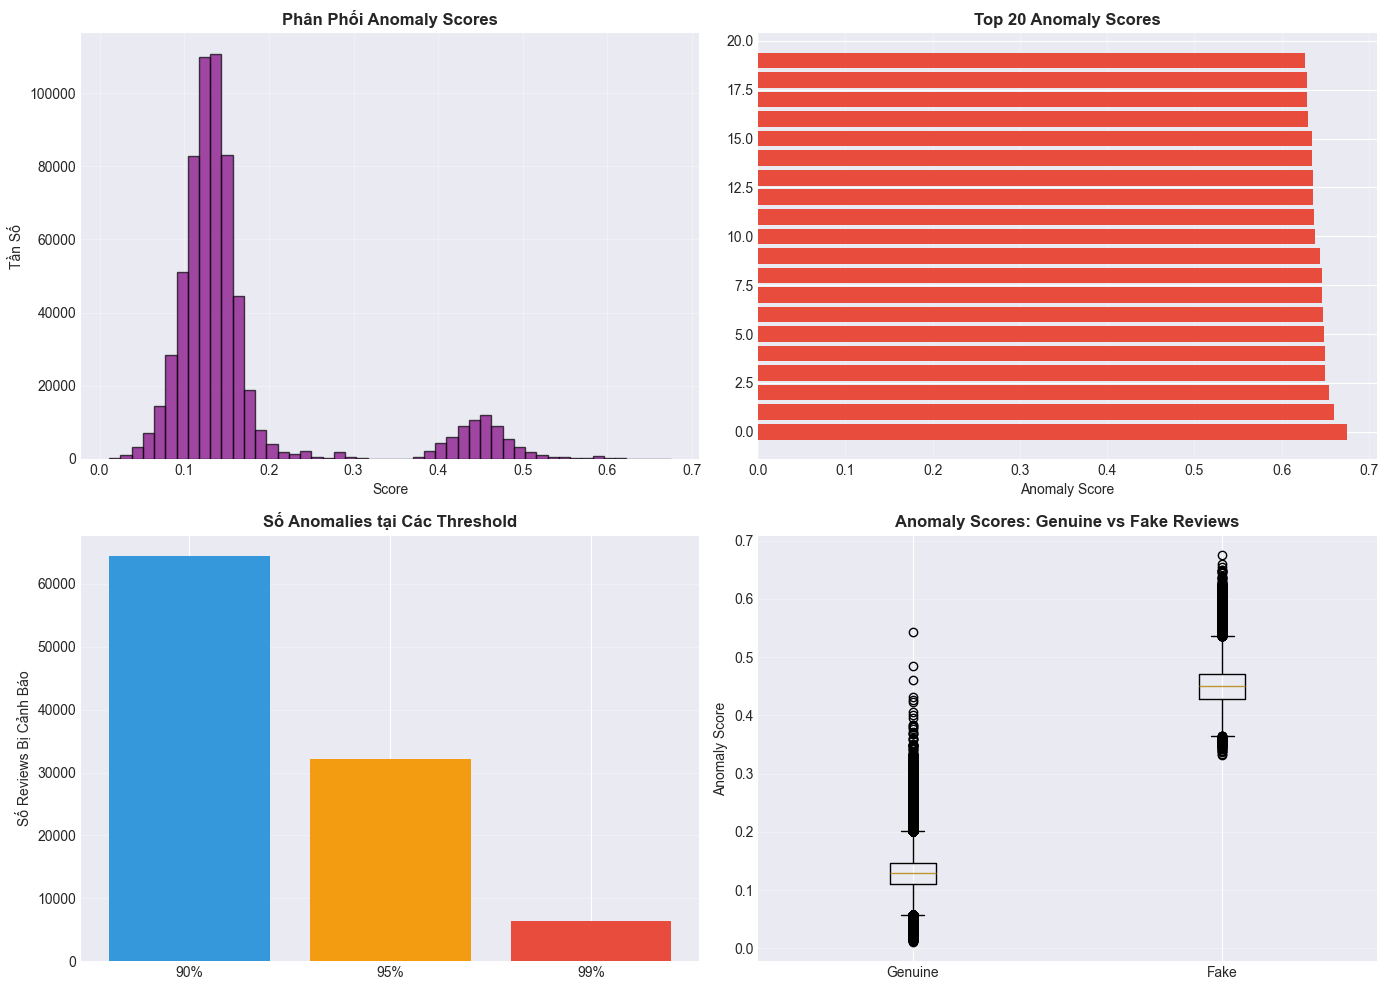

✓ Saved: 05_anomaly_detection.png


In [30]:
if anomaly_scores is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Anomaly scores distribution
    axes[0, 0].hist(anomaly_scores, bins=50, color='purple', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Phân Phối Anomaly Scores', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Score')
    axes[0, 0].set_ylabel('Tần Số')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Top anomalies
    top_n = 20
    top_anomalies_idx = np.argsort(anomaly_scores)[-top_n:][::-1]
    axes[0, 1].barh(range(top_n), anomaly_scores[top_anomalies_idx], color='#e74c3c')
    axes[0, 1].set_title(f'Top {top_n} Anomaly Scores', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Anomaly Score')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Anomaly threshold analysis
    thresholds = np.percentile(anomaly_scores, [90, 95, 99])
    anomaly_counts = [np.sum(anomaly_scores >= t) for t in thresholds]
    axes[1, 0].bar([f'{int(p)}%' for p in [90, 95, 99]], anomaly_counts, color=['#3498db', '#f39c12', '#e74c3c'])
    axes[1, 0].set_title('Số Anomalies tại Các Threshold', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Số Reviews Bị Cảnh Báo')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Anomaly scores vs weak labels
    scores_by_label = [anomaly_scores[review_splits['weak_label'] == 0], 
                       anomaly_scores[review_splits['weak_label'] == 1]]
    axes[1, 1].boxplot(scores_by_label, labels=['Genuine', 'Fake'])
    axes[1, 1].set_title('Anomaly Scores: Genuine vs Fake Reviews', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Anomaly Score')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('05_anomaly_detection.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 05_anomaly_detection.png")
else:
    print("⚠ Anomaly detection results not available")

## 8. Biểu Đồ User & Item Analysis

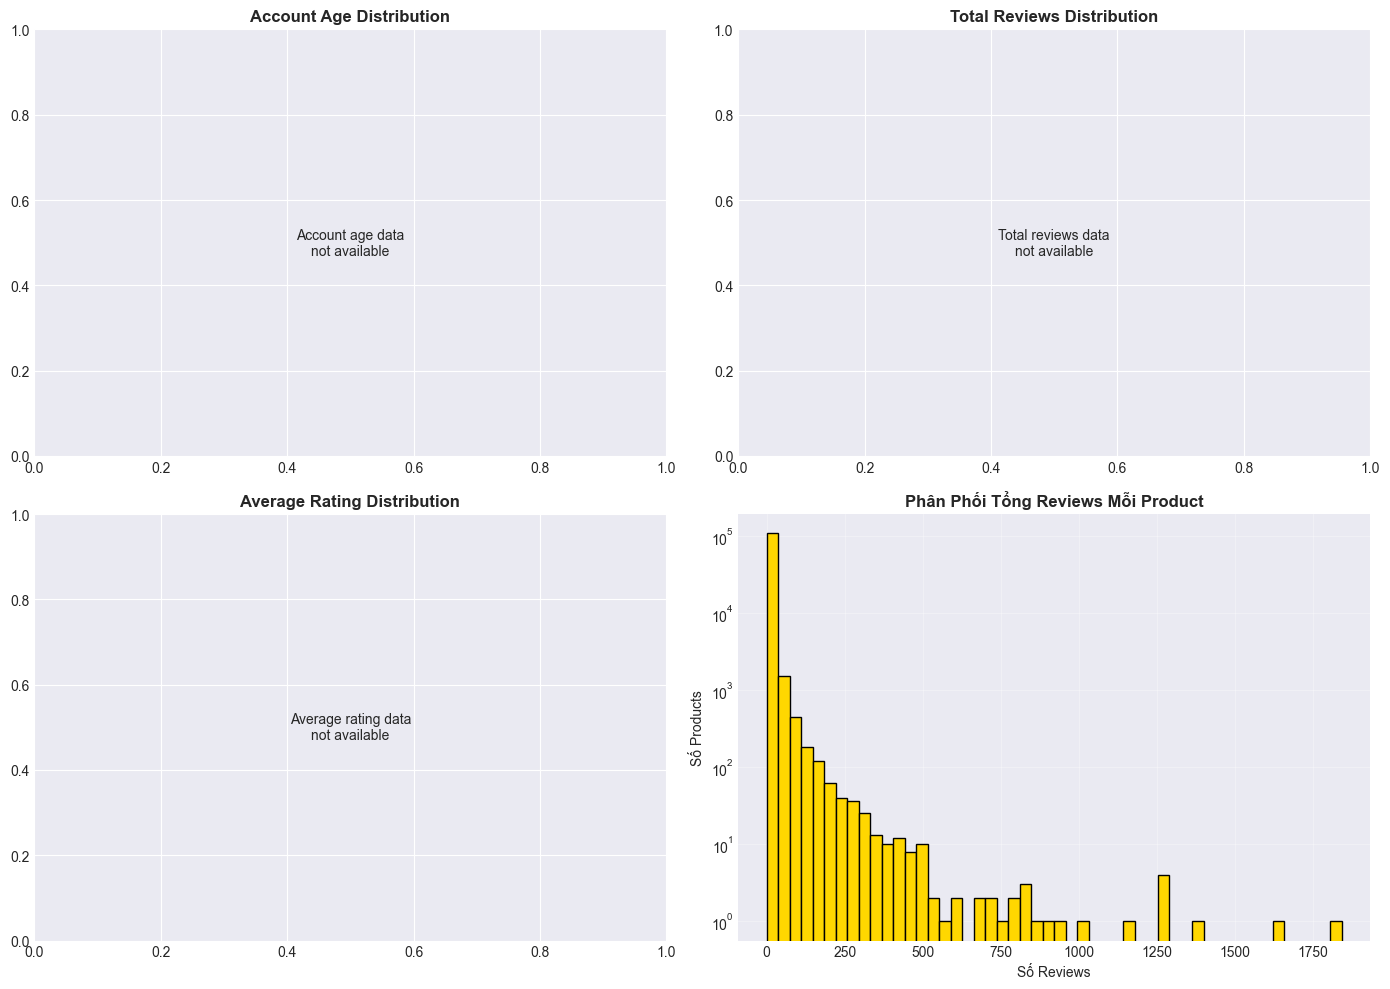

✓ Saved: 06_user_item_analysis.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# User account age distribution
if 'account_age_days' in nodes_user.columns:
    axes[0, 0].hist(nodes_user['account_age_days'].values, bins=50, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Phân Phối Tuổi Tài Khoản Users', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Ngày')
    axes[0, 0].set_ylabel('Số Users')
    axes[0, 0].grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'Account age data\nnot available', 
                     ha='center', va='center', transform=axes[0, 0].transAxes)
    axes[0, 0].set_title('Account Age Distribution', fontsize=12, fontweight='bold')

# User total reviews distribution
if 'total_reviews' in nodes_user.columns:
    axes[0, 1].hist(nodes_user['total_reviews'].values, bins=50, color='lightgreen', edgecolor='black')
    axes[0, 1].set_title('Phân Phối Tổng Reviews Mỗi User', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Tổng Reviews')
    axes[0, 1].set_ylabel('Số Users')
    axes[0, 1].set_yscale('log')
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'Total reviews data\nnot available', 
                     ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Total Reviews Distribution', fontsize=12, fontweight='bold')

# Item average rating
if 'avg_rating' in nodes_item.columns:
    axes[1, 0].hist(nodes_item['avg_rating'].values, bins=50, color='coral', edgecolor='black')
    axes[1, 0].set_title('Phân Phối Rating Trung Bình của Products', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Average Rating')
    axes[1, 0].set_ylabel('Số Products')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Average rating data\nnot available', 
                     ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Average Rating Distribution', fontsize=12, fontweight='bold')

# Item total reviews
item_review_counts = edges_review_item.groupby('dst').size()
axes[1, 1].hist(item_review_counts.values, bins=50, color='gold', edgecolor='black')
axes[1, 1].set_title('Phân Phối Tổng Reviews Mỗi Product', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Số Reviews')
axes[1, 1].set_ylabel('Số Products')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_user_item_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 06_user_item_analysis.png")

## 9. Biểu Đồ Tương Quan Features

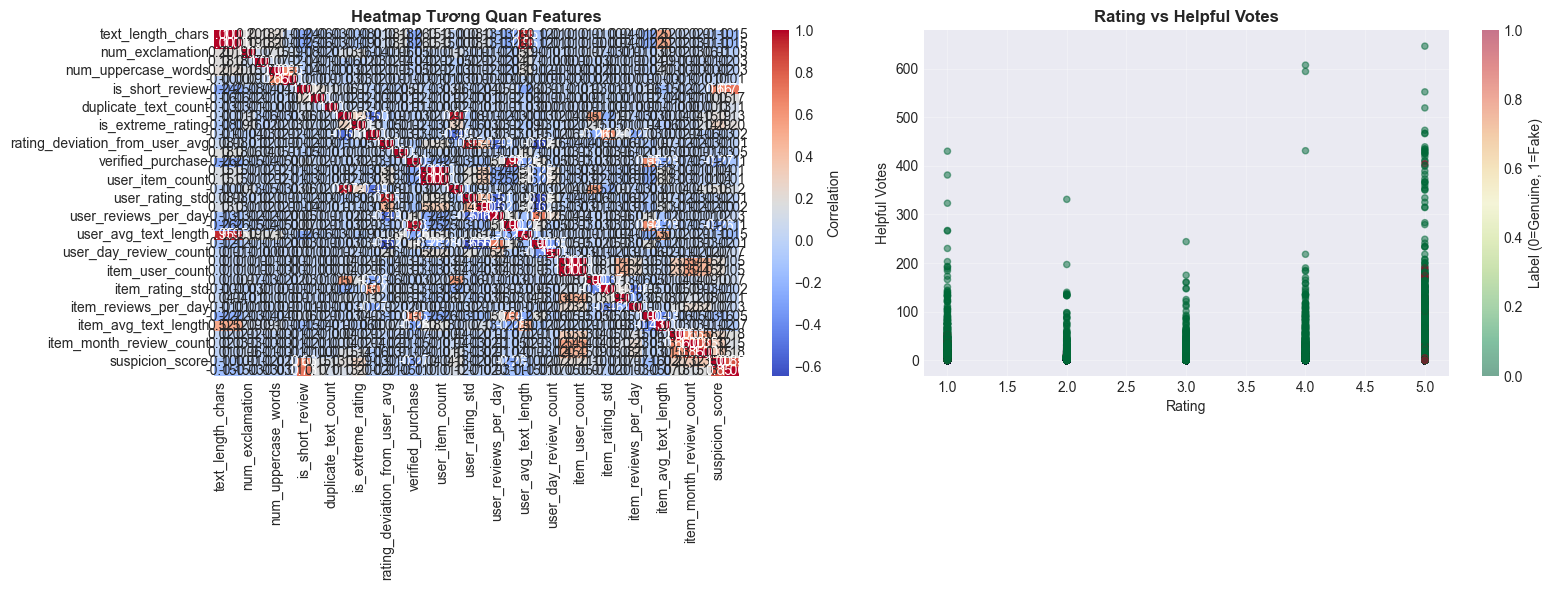

✓ Saved: 07_feature_correlation.png


In [32]:
# Select numeric columns
numeric_cols = review_features.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Correlation heatmap
    try:
        corr_matrix = review_features[numeric_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], cbar_kws={'label': 'Correlation'})
        axes[0].set_title('Heatmap Tương Quan Features', fontsize=12, fontweight='bold')
    except Exception as e:
        axes[0].text(0.5, 0.5, f'Could not compute\ncorrelation: {str(e)[:30]}', 
                     ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('Feature Correlation', fontsize=12, fontweight='bold')
    
    # Rating vs Helpful votes
    if 'helpful_vote' in review_features.columns and 'rating' in review_features.columns:
        try:
            scatter = axes[1].scatter(
                review_features['rating'], 
                review_features['helpful_vote'],
                c=review_splits['weak_label'],
                cmap='RdYlGn_r',
                alpha=0.5,
                s=20
            )
            axes[1].set_title('Rating vs Helpful Votes', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Rating')
            axes[1].set_ylabel('Helpful Votes')
            cbar = plt.colorbar(scatter, ax=axes[1])
            cbar.set_label('Label (0=Genuine, 1=Fake)')
            axes[1].grid(True, alpha=0.3)
        except Exception as e:
            axes[1].text(0.5, 0.5, f'Could not plot\nscatter: {str(e)[:30]}', 
                         ha='center', va='center', transform=axes[1].transAxes)
    else:
        axes[1].text(0.5, 0.5, 'Rating or helpful_vote\ncolumns not available', 
                     ha='center', va='center', transform=axes[1].transAxes)
    
    plt.tight_layout()
    plt.savefig('07_feature_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 07_feature_correlation.png")
else:
    print("⚠ Not enough numeric features for correlation analysis")

## 10. Biểu Đồ Tóm Tắt Thống Kê

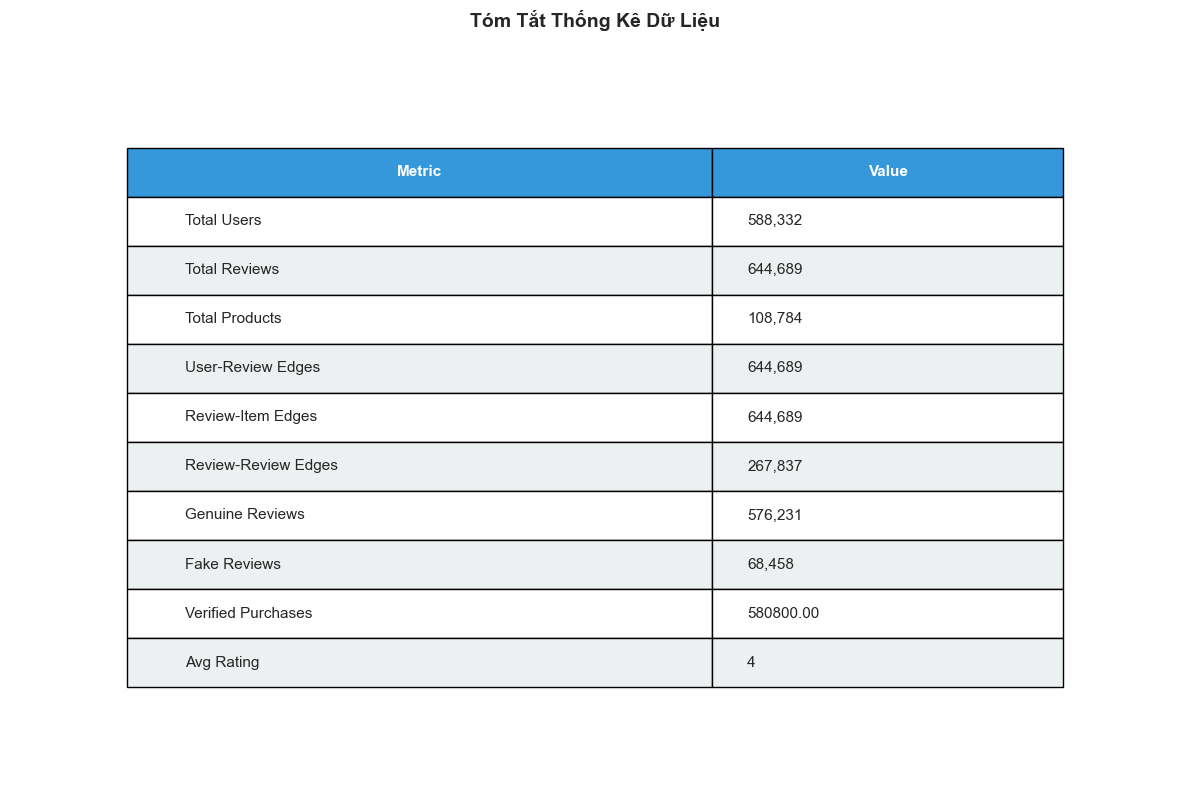

✓ Saved: 08_summary_statistics.png

SUMMARY STATISTICS
Total Users.............................     588332
Total Reviews...........................     644689
Total Products..........................     108784
User-Review Edges.......................     644689
Review-Item Edges.......................     644689
Review-Review Edges.....................     267837
Genuine Reviews.........................     576231
Fake Reviews............................      68458
Verified Purchases......................     580800
Avg Rating.............................. 3.9227379403092035


In [33]:
# Create summary statistics
summary_stats = {
    'Total Users': len(nodes_user),
    'Total Reviews': len(nodes_review),
    'Total Products': len(nodes_item),
    'User-Review Edges': len(edges_user_review),
    'Review-Item Edges': len(edges_review_item),
    'Review-Review Edges': len(edges_review_review),
    'Genuine Reviews': len(review_splits[review_splits['weak_label'] == 0]),
    'Fake Reviews': len(review_splits[review_splits['weak_label'] == 1]),
}

# Add optional stats
if 'verified_purchase' in review_features.columns:
    summary_stats['Verified Purchases'] = review_features['verified_purchase'].sum()
if 'rating' in review_features.columns:
    summary_stats['Avg Rating'] = review_features['rating'].mean()

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# Create table
table_data = [[k, f"{v:,.0f}" if isinstance(v, (int, float)) and v > 1 else f"{v:.2f}"] 
              for k, v in summary_stats.items()]

table = ax.table(
    cellText=table_data,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    loc='center',
    colWidths=[0.5, 0.3]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(len(table_data[0])):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(len(table_data[0])):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.title('Tóm Tắt Thống Kê Dữ Liệu', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('08_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 08_summary_statistics.png")

# Print summary
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
for k, v in summary_stats.items():
    print(f"{k:.<40} {v:>10}")

## 11. Biểu Đồ Temporal Analysis (Nếu có dữ liệu timestamp)

In [34]:
# Check if timestamp data is available
if 'timestamp' in review_features.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Convert to datetime if needed
    try:
        timestamps = pd.to_datetime(review_features['timestamp'])
        
        # Reviews over time
        reviews_per_month = timestamps.dt.to_period('M').value_counts().sort_index()
        axes[0, 0].plot(range(len(reviews_per_month)), reviews_per_month.values, marker='o', color='#3498db')
        axes[0, 0].set_title('Số Reviews Theo Tháng', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Tháng')
        axes[0, 0].set_ylabel('Số Reviews')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Rating over time
        avg_rating_per_month = review_features.groupby(timestamps.dt.to_period('M'))['rating'].mean()
        axes[0, 1].plot(range(len(avg_rating_per_month)), avg_rating_per_month.values, marker='o', color='#e74c3c')
        axes[0, 1].set_title('Rating Trung Bình Theo Tháng', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Tháng')
        axes[0, 1].set_ylabel('Avg Rating')
        axes[0, 1].set_ylim(1, 5)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Reviews by day of week
        day_of_week_counts = timestamps.dt.day_name().value_counts()
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        day_of_week_counts = day_of_week_counts.reindex([d for d in day_order if d in day_of_week_counts.index])
        axes[1, 0].bar(range(len(day_of_week_counts)), day_of_week_counts.values, color='#2ecc71')
        axes[1, 0].set_title('Phân Phối Reviews Theo Ngày Trong Tuần', fontsize=12, fontweight='bold')
        axes[1, 0].set_xticks(range(len(day_of_week_counts)))
        axes[1, 0].set_xticklabels([d[:3] for d in day_of_week_counts.index], rotation=45)
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        
        # Reviews by hour
        hour_counts = timestamps.dt.hour.value_counts().sort_index()
        axes[1, 1].bar(hour_counts.index, hour_counts.values, color='#f39c12')
        axes[1, 1].set_title('Phân Phối Reviews Theo Giờ', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Giờ')
        axes[1, 1].set_ylabel('Số Reviews')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig('09_temporal_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Saved: 09_temporal_analysis.png")
    except Exception as e:
        print(f"⚠ Could not process temporal data: {e}")
else:
    print("⚠ No timestamp data available for temporal analysis")

⚠ No timestamp data available for temporal analysis


## 12. Tóm Tắt Tất Cả Các Đồ Thị

In [35]:
print("\n" + "="*60)
print("📊 TÓM TẮT TẤT CẢ CÁC ĐỒ THỊ ĐÃ XUẤT")
print("="*60)

charts = [
    ("01_data_distribution.png", "Phân Phối Dữ Liệu"),
    ("02_review_features.png", "Đặc Trưng Reviews"),
    ("03_network_statistics.png", "Thống Kê Mạng Lưới"),
    ("03_5_network_visualization.png", "Visualize Mạng Lưới & Nodes"),
    ("03_6_node_attributes.png", "Thuộc Tính Nodes Chi Tiết"),
    ("03_7_detailed_graph_visualization.png", "Graph Visualization Chi Tiết"),
    ("04_weak_labels.png", "Phân Phối Weak Labels"),
    ("05_anomaly_detection.png", "Kết Quả Anomaly Detection"),
    ("06_user_item_analysis.png", "Phân Tích Users & Products"),
    ("07_feature_correlation.png", "Tương Quan Features"),
    ("08_summary_statistics.png", "Tóm Tắt Thống Kê"),
    ("09_temporal_analysis.png", "Phân Tích Theo Thời Gian"),
]

for i, (filename, description) in enumerate(charts, 1):
    file_path = Path(filename)
    if file_path.exists():
        size = file_path.stat().st_size / (1024*1024)  # Convert to MB
        print(f"✓ {i:2d}. {description:.<45} ({size:6.2f} MB)")
    else:
        print(f"✗ {i:2d}. {description:.<45} (Not generated)")

print("\n" + "="*60)
print("✓ All visualizations completed and saved!")
print("="*60)


📊 TÓM TẮT TẤT CẢ CÁC ĐỒ THỊ ĐÃ XUẤT
✓  1. Phân Phối Dữ Liệu............................ (  0.24 MB)
✓  2. Đặc Trưng Reviews............................ (  0.22 MB)
✓  3. Thống Kê Mạng Lưới........................... (  0.25 MB)
✓  4. Visualize Mạng Lưới & Nodes.................. (  1.05 MB)
✓  5. Thuộc Tính Nodes Chi Tiết.................... (  0.57 MB)
✓  6. Graph Visualization Chi Tiết................. (  1.32 MB)
✓  7. Phân Phối Weak Labels........................ (  0.28 MB)
✓  8. Kết Quả Anomaly Detection.................... (  0.26 MB)
✓  9. Phân Tích Users & Products................... (  0.20 MB)
✓ 10. Tương Quan Features.......................... (  1.98 MB)
✓ 11. Tóm Tắt Thống Kê............................. (  0.18 MB)
✗ 12. Phân Tích Theo Thời Gian..................... (Not generated)

✓ All visualizations completed and saved!
